# Algorithm performance measurement and benchmarking tool

**Course:** ENCA351 Design and Analysis of Algorithms Lab, BCA (AI&DS) Semester V
**Lab assignment 2**  
**Student:** Shreyansh Vaibhaw, roll number 2401201094

This notebook walks through every part of the project: the search module, the code
benchmarking module, the automated engine, the charts, the complexity table and the
comparative study. The same modules power the Streamlit app (`streamlit run app.py`).

Each experiment is run live in this notebook, so the numbers below come from the machine
the notebook was last executed on. The saved CSV in `results/` is the reference run used
in the final report.

## 1. Setup

The notebook imports the project modules from the repository root. Set `QUICK_MODE = True`
to cap the nested loop at 10,000 iterations, which cuts the automated run from about six
minutes to about twenty seconds.

In [1]:
import sys, time
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "benchmark_engine.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from search_analysis import generate_dataset, choose_key, linear_search, binary_search, max_binary_comparisons
from code_benchmark import CODE_SNIPPETS, single_loop, nested_loop, factorial_recursive, factorial_iterative
from benchmark_engine import (BenchmarkEngine, run_automated_suite, DEFAULT_INPUT_SIZES,
                              format_seconds, format_kb, environment_info, tracing_overhead_factor)
from complexity_analysis import theoretical_table, build_complexity_table, growth_factor_table, pairwise_speedup
from visualization import (plot_time, plot_memory, plot_operations, plot_overview,
                           plot_growth_exponents, summarize_trends, generate_all_charts)
# the project modules select the Agg backend, so turn inline plotting on after importing them
%matplotlib inline

QUICK_MODE = False

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.DataFrame(environment_info().items(), columns=["setting", "value"])

,setting,value
0,python,3.12.10
1,implementation,CPython
2,os,Windows-11-10.0.26200-SP0
3,processor,"Intel64 Family 6 Model 142 Stepping 12, Genuin..."
4,cpu_count,8
5,timer,time.perf_counter
6,memory,tracemalloc peak heap (separate run)
7,recorded_at,2026-09-28 11:59:36


## 2. Search algorithm analysis (Task 2)

The digital-library scenario: records are looked up by key in catalogues of growing size.
`generate_dataset` produces distinct sorted integers, `linear_search` and `binary_search`
return the index and the number of key comparisons.

In [2]:
data = generate_dataset(20, seed=7)
print("dataset:", data)
for key in (choose_key(data, present=True, seed=7), choose_key(data, present=False)):
    print(linear_search(data, key).describe())
    print(binary_search(data, key).describe())

dataset: [9, 12, 14, 17, 18, 22, 23, 24, 38, 54, 61, 82, 93, 101, 107, 111, 129, 137, 149, 166]
Linear Search: key 61 found at index 10 after 11 comparisons
Binary Search: key 61 found at index 10 after 4 comparisons
Linear Search: key -1 not found after 20 comparisons
Binary Search: key -1 not found after 4 comparisons


The engine times the call and measures its memory in a separate traced run. The key is
absent, which is the worst case for both algorithms.

In [3]:
engine = BenchmarkEngine()
rows = []
for n in [100, 1_000, 10_000, 50_000]:
    data = generate_dataset(n, seed=42)
    key = choose_key(data, present=False)
    for name, func in (("Linear Search", linear_search), ("Binary Search", binary_search)):
        m = engine.measure(func, (data, key), name=name, group="search", input_size=n)
        rows.append({"algorithm": name, "n": n, "found": func(data, key).found,
                     "comparisons": m.operations, "worst-case bound": n if name == "Linear Search" else max_binary_comparisons(n),
                     "time": format_seconds(m.time_sec), "memory": format_kb(m.memory_kb), "timed runs": m.runs})
pd.DataFrame(rows)

,algorithm,n,found,comparisons,worst-case bound,time,memory,timed runs
0,Linear Search,100,False,100,100,25.2 us,288 bytes,1000
1,Binary Search,100,False,6,7,6.9 us,288 bytes,1000
2,Linear Search,1000,False,1000,1000,390.2 us,376 bytes,104
3,Binary Search,1000,False,9,10,9.5 us,316 bytes,1000
4,Linear Search,10000,False,10000,10000,6.71 ms,376 bytes,8
5,Binary Search,10000,False,13,14,11.8 us,316 bytes,1000
6,Linear Search,50000,False,50000,50000,34.02 ms,376 bytes,5
7,Binary Search,50000,False,15,16,13.5 us,316 bytes,1000


## 3. Code benchmarking module (Task 3)

Four program structures a development team meets every day. Loop snippets run with
n = 1,000 iterations and the factorials with n = 1,000.

In [4]:
engine = BenchmarkEngine()
rows = []
for name, func in CODE_SNIPPETS.items():
    n = 1_000
    m = engine.measure(func, (n,), name=name, group="snippet", input_size=n)
    rows.append({"snippet": name, "n": n, "operations": m.operations, "time": format_seconds(m.time_sec),
                 "memory": format_kb(m.memory_kb), "result": m.result_summary})
snippets = pd.DataFrame(rows)
snippets

,snippet,n,operations,time,memory,result
0,Single Loop Traversal,1000,1000,230.9 us,288 bytes,499500
1,Nested Loop Traversal,1000,1000000,218.96 ms,1.98 KB,1000000
2,Recursive Factorial,1000,1000,773.2 us,23.77 KB,2568-digit integer (402387260077...)
3,Iterative Factorial,1000,999,512.7 us,2.39 KB,2568-digit integer (402387260077...)


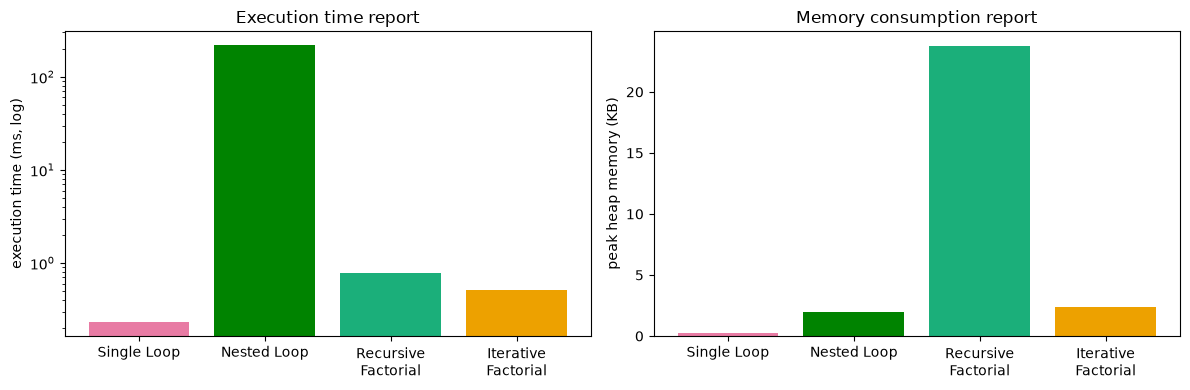

In [5]:
frame = engine.as_dataframe()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(frame["algorithm"], frame["time_ms"], color=["#e87ba4", "#008300", "#1baf7a", "#eda100"])
axes[0].set_yscale("log"); axes[0].set_ylabel("execution time (ms, log)"); axes[0].set_title("Execution time report")
axes[1].bar(frame["algorithm"], frame["memory_kb"], color=["#e87ba4", "#008300", "#1baf7a", "#eda100"])
axes[1].set_ylabel("peak heap memory (KB)"); axes[1].set_title("Memory consumption report")
for ax in axes:
    ax.set_xticks(range(4)); ax.set_xticklabels([a.replace(" Traversal", "").replace(" Factorial", "\nFactorial") for a in frame["algorithm"]])
plt.tight_layout()

## 4. Automated benchmarking engine (Task 4)

`run_automated_suite` runs every algorithm across the assignment's input sizes:
searches at 100 / 1,000 / 10,000 / 50,000 elements, factorials at n = 100 / 500 / 1,000,
loops at 100 / 1,000 / 10,000 / 50,000 iterations.

Two measurement details matter here.

* Timing and memory tracing happen in separate runs. Tracing every allocation slows a
  tight loop by the factor printed below, so timing a traced run would measure the profiler.
* The engine predicts how long a traced run would take. When the prediction exceeds the
  30 s budget it skips the memory pass and records the reason in `memory_method`. That is
  what happens for the nested loop at 10,000 and 50,000 iterations; tracing the 2.5 billion
  allocations of the largest case would take hours.

In [6]:
print(f"tracemalloc slows an allocation-heavy loop by about {tracing_overhead_factor():.0f}x on this machine")

sizes = {"loops": [100, 1_000, 10_000]} if QUICK_MODE else None
engine = BenchmarkEngine()
started = time.perf_counter()
results = run_automated_suite(sizes, engine=engine,
                              on_progress=lambda done, total, label: print(f"[{done:>2}/{total}] {label}"))
print(f"\nsuite finished in {format_seconds(time.perf_counter() - started)}")
engine.save_csv(ROOT / "results" / "notebook_results.csv")
results[["algorithm", "input_size", "time_ms", "memory_kb", "operations", "runs", "memory_method"]]

tracemalloc slows an allocation-heavy loop by about 40x on this machine
[ 0/22] Linear Search (n = 100)
[ 1/22] Linear Search (n = 1,000)
[ 2/22] Linear Search (n = 10,000)


[ 3/22] Linear Search (n = 50,000)


[ 4/22] Binary Search (n = 100)
[ 5/22] Binary Search (n = 1,000)


[ 6/22] Binary Search (n = 10,000)
[ 7/22] Binary Search (n = 50,000)


[ 8/22] Recursive Factorial (n = 100)
[ 9/22] Recursive Factorial (n = 500)


...

[20/22] Nested Loop Traversal (n = 10,000)


[21/22] Nested Loop Traversal (n = 50,000)


[22/22] Benchmark complete



suite finished in 320.18 s


,algorithm,input_size,time_ms,memory_kb,operations,runs,memory_method
0,Linear Search,100,0.01260,0.281250,100,1000,tracemalloc (peak heap)
1,Linear Search,1000,0.16790,0.367188,1000,263,tracemalloc (peak heap)
2,Linear Search,10000,4.40695,1.573242,10000,10,tracemalloc (peak heap)
3,Linear Search,50000,24.54260,0.432617,50000,5,tracemalloc (peak heap)
4,Binary Search,100,0.00570,0.281250,6,1000,tracemalloc (peak heap)
5,Binary Search,1000,0.00830,0.253906,9,1000,tracemalloc (peak heap)
6,Binary Search,10000,0.01120,0.308594,13,1000,tracemalloc (peak heap)
7,Binary Search,50000,0.01390,0.308594,15,1000,tracemalloc (peak heap)
8,Recursive Factorial,100,0.05190,0.316406,100,871,tracemalloc (peak heap)
9,Recursive Factorial,500,0.57620,8.089844,500,77,tracemalloc (peak heap)


In [7]:
results.pivot_table(index="algorithm", columns="input_size", values="time_ms", aggfunc="first").round(4)

input_size,100,500,1000,10000,50000
algorithm,,,,,
Binary Search,0.0057,NaN,0.0083,0.0112,0.0139
Iterative Factorial,0.0333,0.1883,0.7743,NaN,NaN
Linear Search,0.0126,NaN,0.1679,4.4069,24.5426
Nested Loop Traversal,0.9208,NaN,141.9433,8352.6038,302208.8015
Recursive Factorial,0.0519,0.5762,1.7189,NaN,NaN
Single Loop Traversal,0.0091,NaN,0.1095,1.1922,7.5033


## 5. Performance visualization (Task 5)

One fixed colour per algorithm across every chart. The right-hand chart of each pair
shows peak heap memory from the traced run.

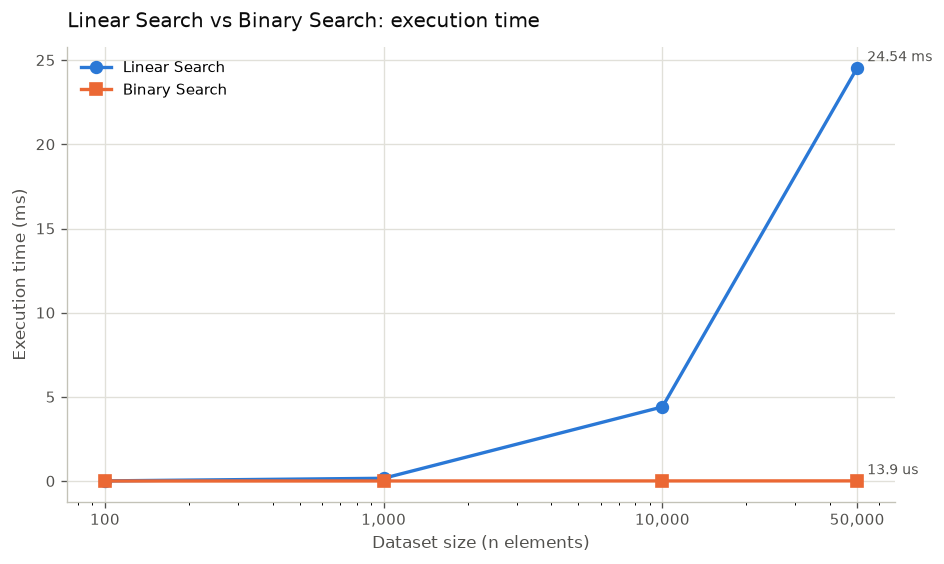

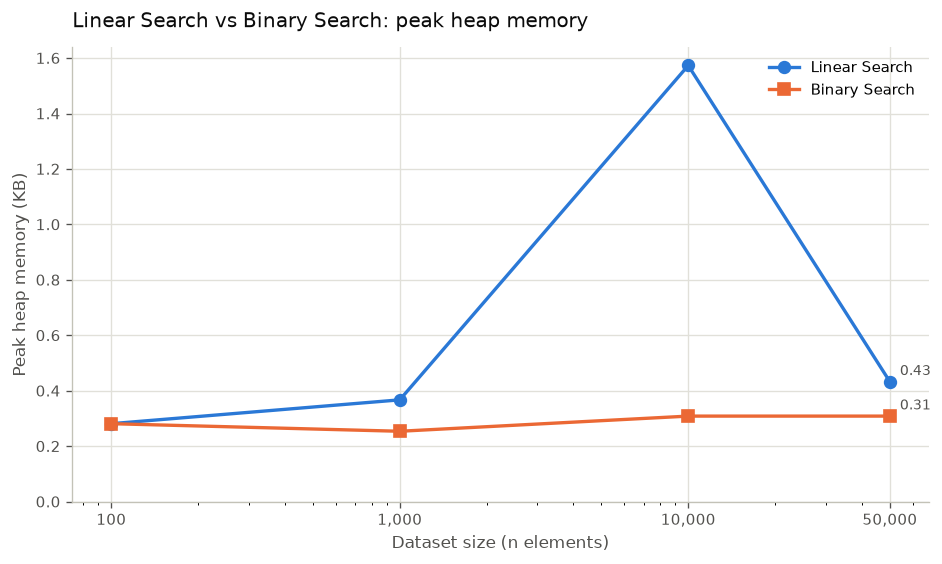

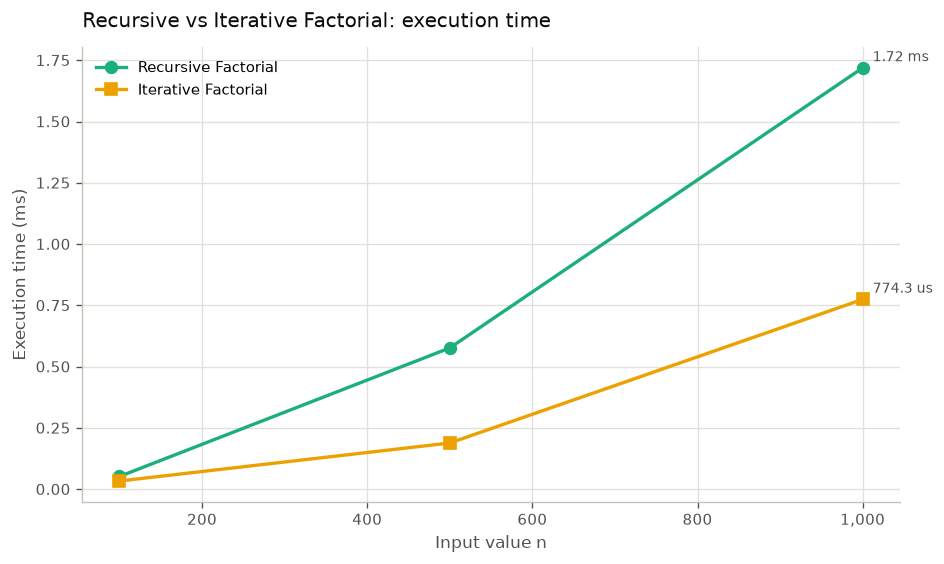

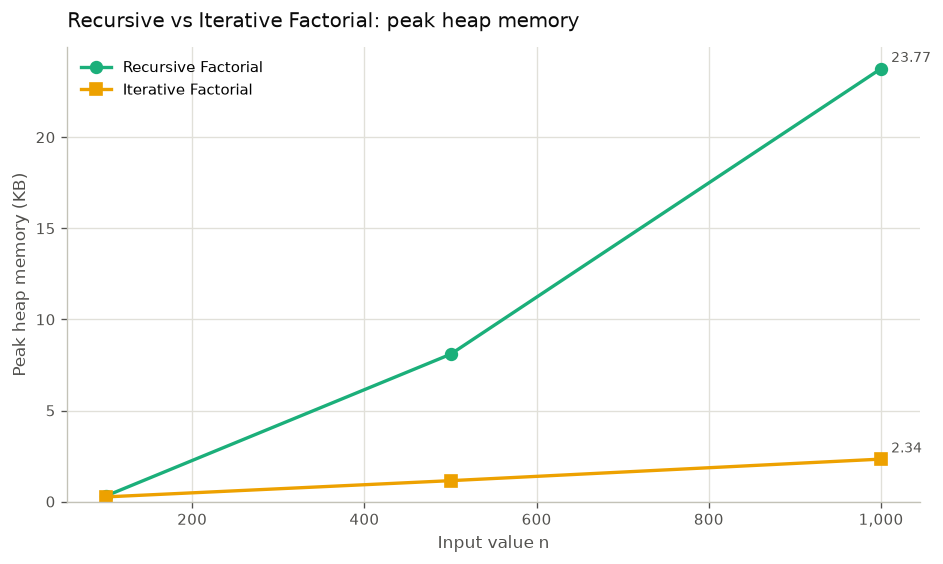

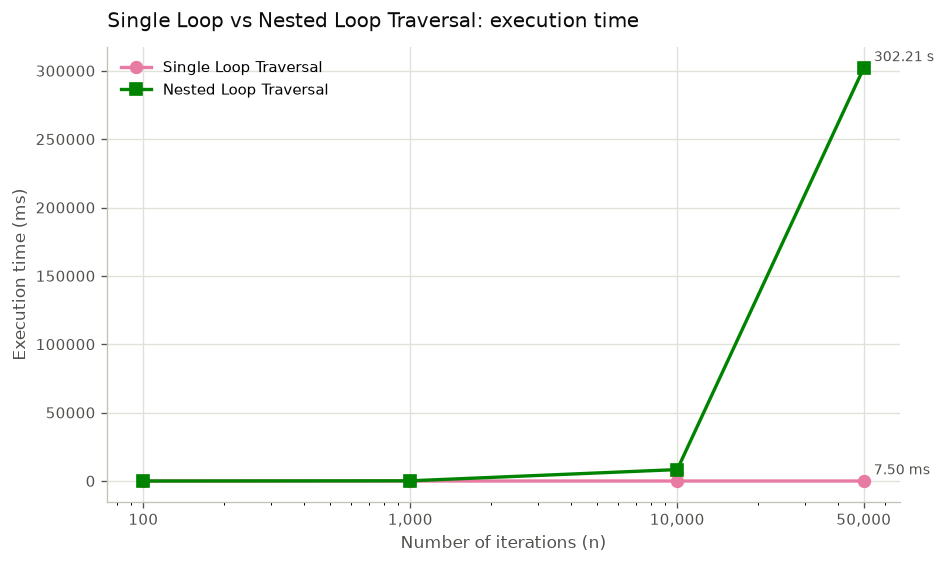

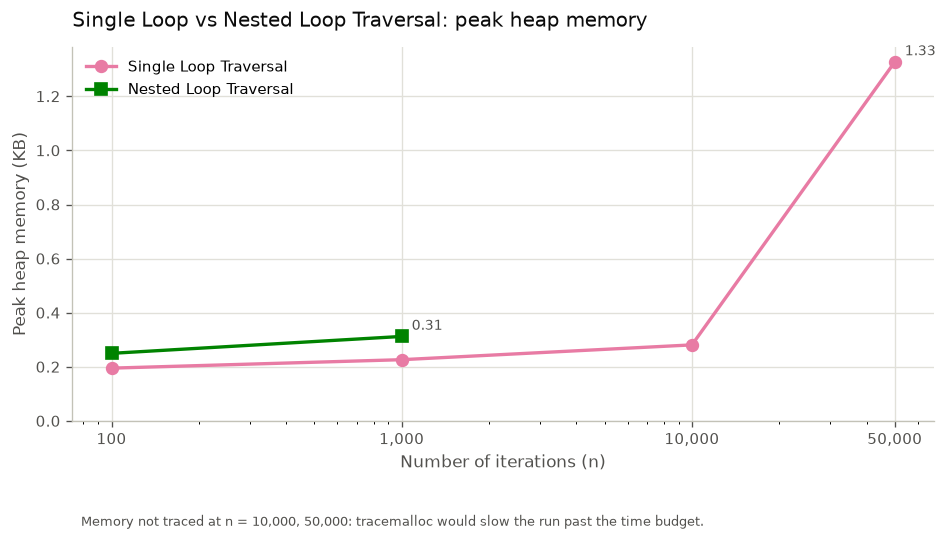

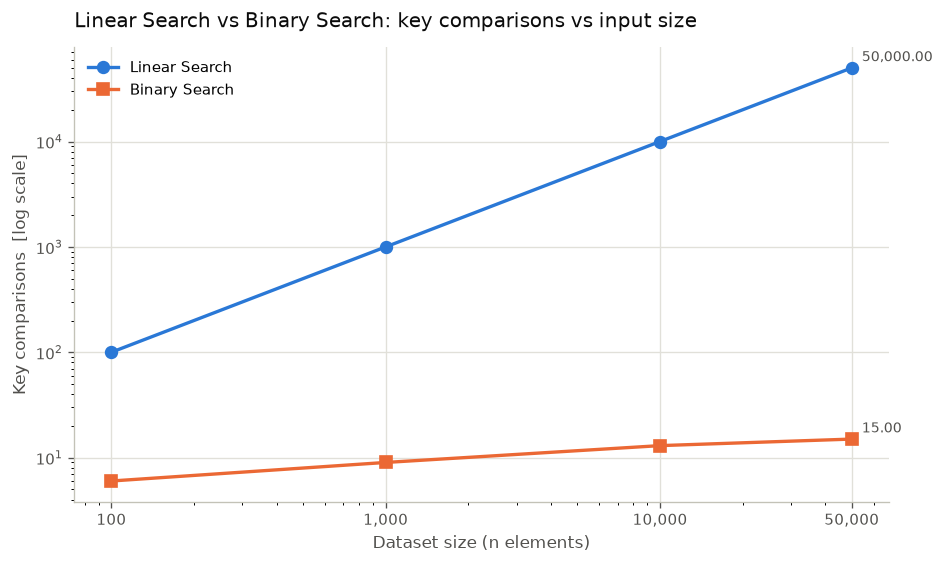

In [8]:
for group in ("search", "factorial", "loops"):
    display(plot_time(results, group))
    display(plot_memory(results, group))
display(plot_operations(results, "search"))
plt.close("all")

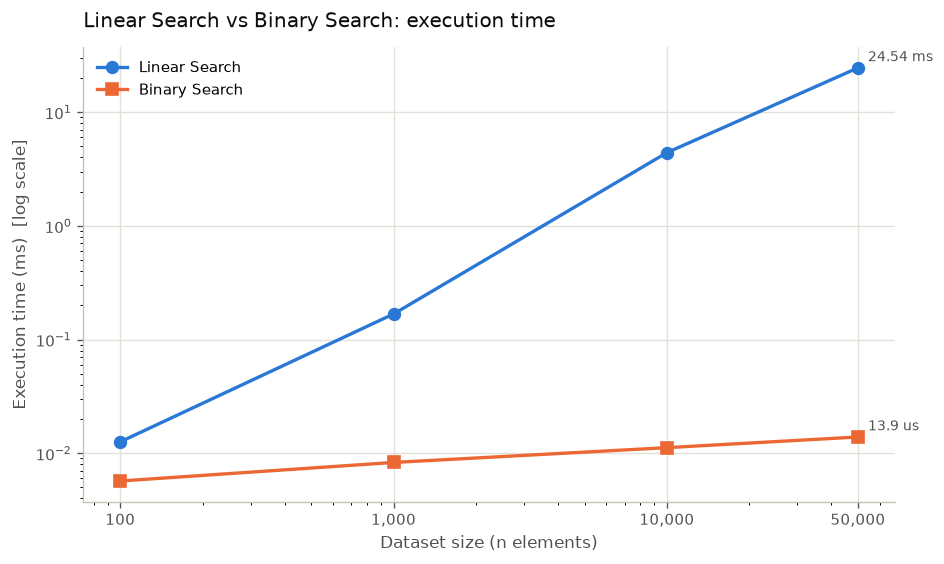

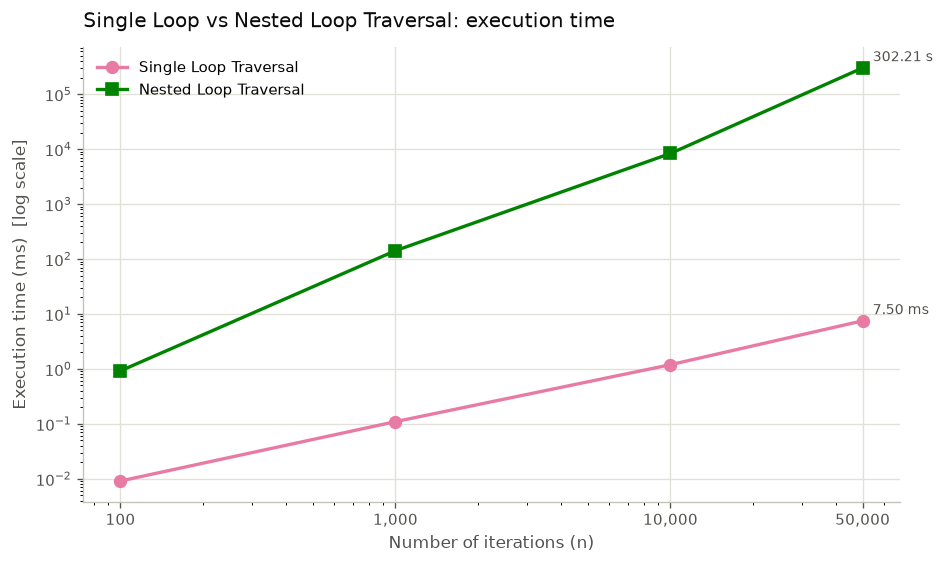

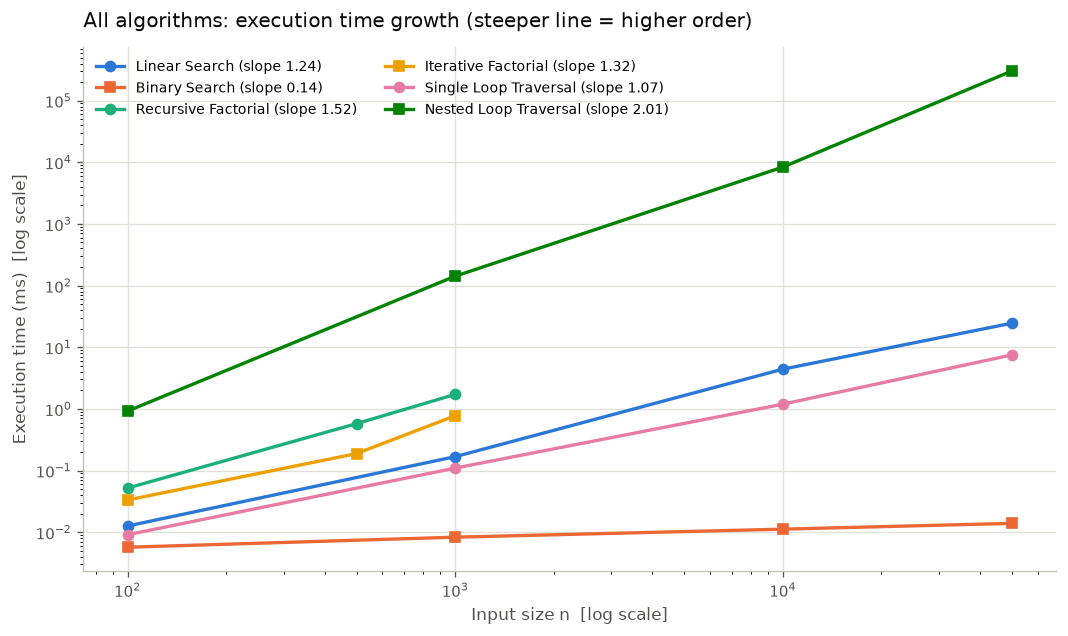

- Linear Search: input grew 500x from 100 to 50,000; time grew 1,947.8x from 12.6 us to 24.54 ms (log-log slope 1.24).
- Binary Search: input grew 500x from 100 to 50,000; time grew 2.4x from 5.7 us to 13.9 us (log-log slope 0.14).
- At n = 50,000, Binary Search is 1,765.7x faster than Linear Search.
- Recursive Factorial: input grew 10x from 100 to 1,000; time grew 33.1x from 51.9 us to 1.72 ms (log-log slope 1.52).
- Iterative Factorial: input grew 10x from 100 to 1,000; time grew 23.3x from 33.3 us to 774.3 us (log-log slope 1.32).
- At n = 1,000, Iterative Factorial is 2.2x faster than Recursive Factorial.
- Single Loop Traversal: input grew 500x from 100 to 50,000; time grew 824.5x from 9.1 us to 7.50 ms (log-log slope 1.07).
- Nested Loop Traversal: input grew 500x from 100 to 50,000; time grew 328,202.4x from 920.8 us to 302.21 s (log-log slope 2.01).
- At n = 50,000, Single Loop Traversal is 40,276.8x faster than Nested Loop Traversal.


In [9]:
display(plot_time(results, "search", log_y=True))
display(plot_time(results, "loops", log_y=True))
display(plot_overview(results))
plt.close("all")
for line in summarize_trends(results):
    print("-", line)

## 6. Complexity analysis (Task 6)

The observed exponent is the slope of a straight-line fit to log(time) against log(n).
Slope 1 means linear growth, slope 2 quadratic, slope near 0 constant or logarithmic.

In [10]:
theoretical_table()

,Algorithm / Program,Best Case,Average Case,Worst Case,Time Complexity,Space Complexity,Note
0,Linear Search,O(1),O(n),O(n),O(n),O(1),Examines every element when the key is absent.
1,Binary Search,O(1),O(log n),O(log n),O(log n),O(1),Needs sorted input; halves the interval each p...
2,Recursive Factorial,O(n),O(n),O(n),O(n),O(n),n stack frames; the default recursion limit (1...
3,Iterative Factorial,O(n),O(n),O(n),O(n),O(1),"One accumulator, no extra frames."
4,Single Loop Traversal,O(n),O(n),O(n),O(n),O(1),One pass over n items.
5,Nested Loop Traversal,O(n^2),O(n^2),O(n^2),O(n^2),O(1),n*n inner iterations.


In [11]:
table = build_complexity_table(results)
table["Time at n (min)"] = table["Time at n (min)"].map(format_seconds)
table["Time at n (max)"] = table["Time at n (max)"].map(format_seconds)
table.round(2)

,Algorithm / Program,Theoretical Time,Theoretical Space,n (min),Time at n (min),n (max),Time at n (max),Time growth (max/min),Peak memory min (KB),Peak memory max (KB),Observed exponent,Observed growth trend,Verdict
0,Linear Search,O(n),O(1),100,12.6 us,50000,24.54 ms,1947.77,0.28,1.57,1.24,linear,matches theory
1,Binary Search,O(log n),O(1),100,5.7 us,50000,13.9 us,2.44,0.25,0.31,0.14,constant / logarithmic,matches theory
2,Recursive Factorial,O(n),O(n),100,51.9 us,1000,1.72 ms,33.12,0.32,23.77,1.52,between linear and quadratic (n log n-like),grows faster than the bound predicts
3,Iterative Factorial,O(n),O(1),100,33.3 us,1000,774.3 us,23.25,0.26,2.34,1.32,between linear and quadratic (n log n-like),grows faster than the bound predicts
4,Single Loop Traversal,O(n),O(1),100,9.1 us,50000,7.50 ms,824.54,0.20,1.33,1.07,linear,matches theory
5,Nested Loop Traversal,O(n^2),O(1),100,920.8 us,50000,302.21 s,328202.42,0.25,0.31,2.01,quadratic,matches theory


execution time relative to the smallest input size


input_size,100,500,1000,10000,50000
algorithm,,,,,
Linear Search,1.0,NaN,13.3,349.7,1947.8
Binary Search,1.0,NaN,1.5,2.0,2.4
Recursive Factorial,1.0,11.1,33.1,NaN,NaN
Iterative Factorial,1.0,5.7,23.3,NaN,NaN
Single Loop Traversal,1.0,NaN,12.0,131.0,824.5
Nested Loop Traversal,1.0,NaN,154.2,9071.0,328202.4


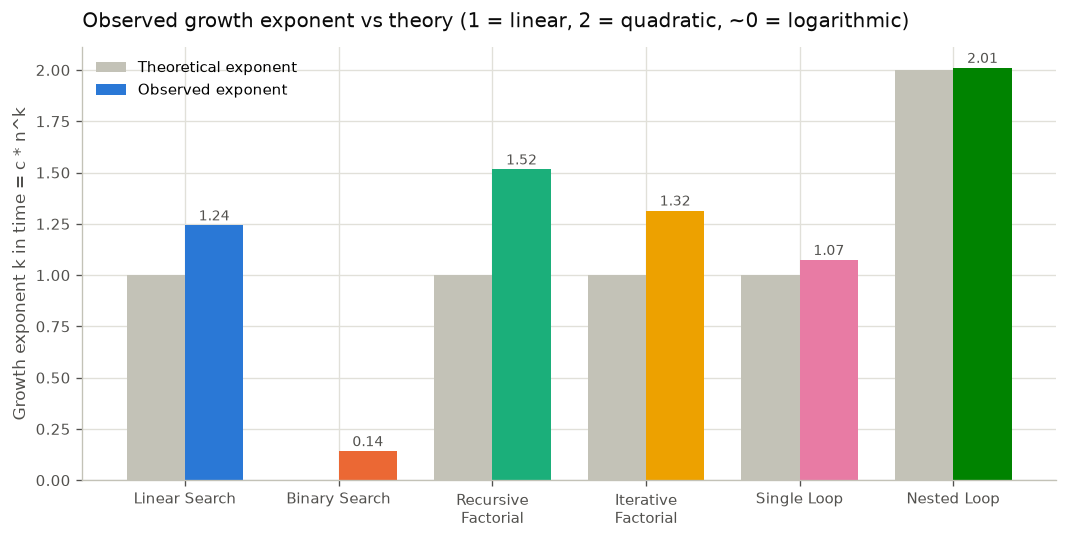

In [12]:
print("execution time relative to the smallest input size")
display(growth_factor_table(results).round(1))
display(plot_growth_exponents(results))
plt.close("all")

Reading the table:

* Linear search, the single loop and the nested loop land close to their theoretical
  exponents of 1, 1 and 2.
* Binary search stays at a few microseconds for every size, so the fixed cost of a
  function call and of the timer dominates and the slope is near zero rather than a
  clean logarithm.
* Both factorials grow faster than O(n). Python integers have arbitrary precision, 1000!
  has 2,568 digits, and multiplying a number that long is not a constant-time step. The
  O(n) bound counts multiplications, not the digits each one touches.
* The recursive factorial's heap grows linearly with n because each open call keeps its
  own integer argument alive, one per frame. The interpreter frames themselves live
  outside the traced heap, so the real stack cost is larger than the number shown.

## 7. Comparative performance study (Task 7)

In [13]:
print("Linear vs binary search (speedup = linear time / binary time)")
display(pairwise_speedup(results, "Binary Search", "Linear Search").round(6))
print("Recursive vs iterative factorial (speedup = recursive time / iterative time)")
display(pairwise_speedup(results, "Iterative Factorial", "Recursive Factorial").round(6))
print("Single vs nested loop (speedup = nested time / single time)")
display(pairwise_speedup(results, "Single Loop Traversal", "Nested Loop Traversal").round(6))

Linear vs binary search (speedup = linear time / binary time)


,input_size,Binary Search (s),Linear Search (s),speedup (x)
0,100,0.000006,0.000013,2.210522
1,1000,0.000008,0.000168,20.229017
2,10000,0.000011,0.004407,393.474680
3,50000,0.000014,0.024543,1765.656013


Recursive vs iterative factorial (speedup = recursive time / iterative time)


,input_size,Iterative Factorial (s),Recursive Factorial (s),speedup (x)
0,100,0.000033,0.000052,1.558557
1,500,0.000188,0.000576,3.059198
2,1000,0.000774,0.001719,2.219942


Single vs nested loop (speedup = nested time / single time)


,input_size,Single Loop Traversal (s),Nested Loop Traversal (s),speedup (x)
0,100,0.000009,0.000921,101.187340
1,1000,0.000110,0.141943,1296.282866
2,10000,0.001192,8.352604,7006.042457
3,50000,0.007503,302.208802,40276.785221


**Linear search vs binary search.** Binary search wins at every size and the gap widens
with n: doubling the catalogue doubles the linear scan's work and adds one probe to the
binary search. The catch is the sorted-input precondition. For data that is searched once,
sorting (O(n log n)) costs more than the scan it replaces; for a catalogue searched many
times the sort is paid once and every lookup benefits.

**Recursive vs iterative factorial.** Both do the same n - 1 multiplications, so their
times stay within a small factor; the recursive version pays a function call per level.
Memory is where they differ. Each open recursive call holds its own argument and frame, so
memory grows with n, and Python refuses to go past 1,000 frames unless the limit is raised.
The loop keeps one accumulator. Iteration is the safer choice for input that may grow.

**Single vs nested loop.** n steps against n squared. Multiplying n by 10 multiplies the
nested loop's time by roughly 100, which is exactly what makes a quadratic routine
unusable on inputs a linear one handles without effort. Neither needs memory beyond a
few counters.

**Time-space trade-offs.** Binary search trades preparation time for cheap queries. The
recursive factorial trades memory for code that mirrors the definition. Measurement has a
cost too: tracing memory slowed the loops 25x to 60x, which is why the engine measures
time and memory in separate runs and skips traces that would take hours.

## 8. Process-level memory with memory_profiler

`tracemalloc` counts bytes allocated on the Python heap. `memory_profiler` reads the
whole process's resident set size through `psutil`, at page granularity. The engine
offers it as an alternative backend; the sampler runs in a thread so it works inside a
notebook kernel and inside Streamlit. For algorithms this small the process-level view
usually reports zero growth, which is itself a useful sanity check.

In [14]:
engine_rss = BenchmarkEngine(memory_backend="memory_profiler")
rows = []
for name, func, arg in (("Recursive Factorial", factorial_recursive, 1_000),
                        ("Iterative Factorial", factorial_iterative, 1_000),
                        ("Linear Search", linear_search, None)):
    args = (generate_dataset(50_000, seed=42), -1) if arg is None else (arg,)
    m = engine_rss.measure(func, args, name=name, group="rss", input_size=arg or 50_000)
    rows.append({"algorithm": name, "n": m.input_size, "time": format_seconds(m.time_sec),
                 "process RSS growth": format_kb(m.memory_kb), "method": m.memory_method})
pd.DataFrame(rows)

,algorithm,n,time,process RSS growth,method
0,Recursive Factorial,1000,497.4 us,64.00 KB,memory_profiler (process RSS)
1,Iterative Factorial,1000,362.7 us,20.00 KB,memory_profiler (process RSS)
2,Linear Search,50000,8.27 ms,20.00 KB,memory_profiler (process RSS)


## 9. Conclusion

* The measurements reproduce the textbook ordering: O(log n) binary search beats O(n)
  linear search by a factor that grows with n, and the O(n squared) nested loop is
  already impractical at 50,000 iterations while the O(n) loop finishes in milliseconds.
* Big-O hides constants and machine effects. Binary search is dominated by call overhead
  at these sizes, and Python's arbitrary-precision integers push both factorials above
  linear growth.
* Recursion costs memory that the loop does not need, and Python enforces that cost with
  a hard recursion limit.
* Good measurement needs care: separate timing from tracing, repeat fast calls, exclude
  input generation, and be honest about what a profiler can and cannot see.

Charts are saved to `graphs/` by the cell below (the reference set in the repository
comes from `python run_benchmarks.py`).

In [15]:
paths = generate_all_charts(results, ROOT / "graphs" / "notebook")
print(f"saved {len(paths)} charts to {ROOT / 'graphs' / 'notebook'}")

saved 11 charts to C:\dev\DAA LAB - 2\graphs\notebook
